Calculating daily returns...


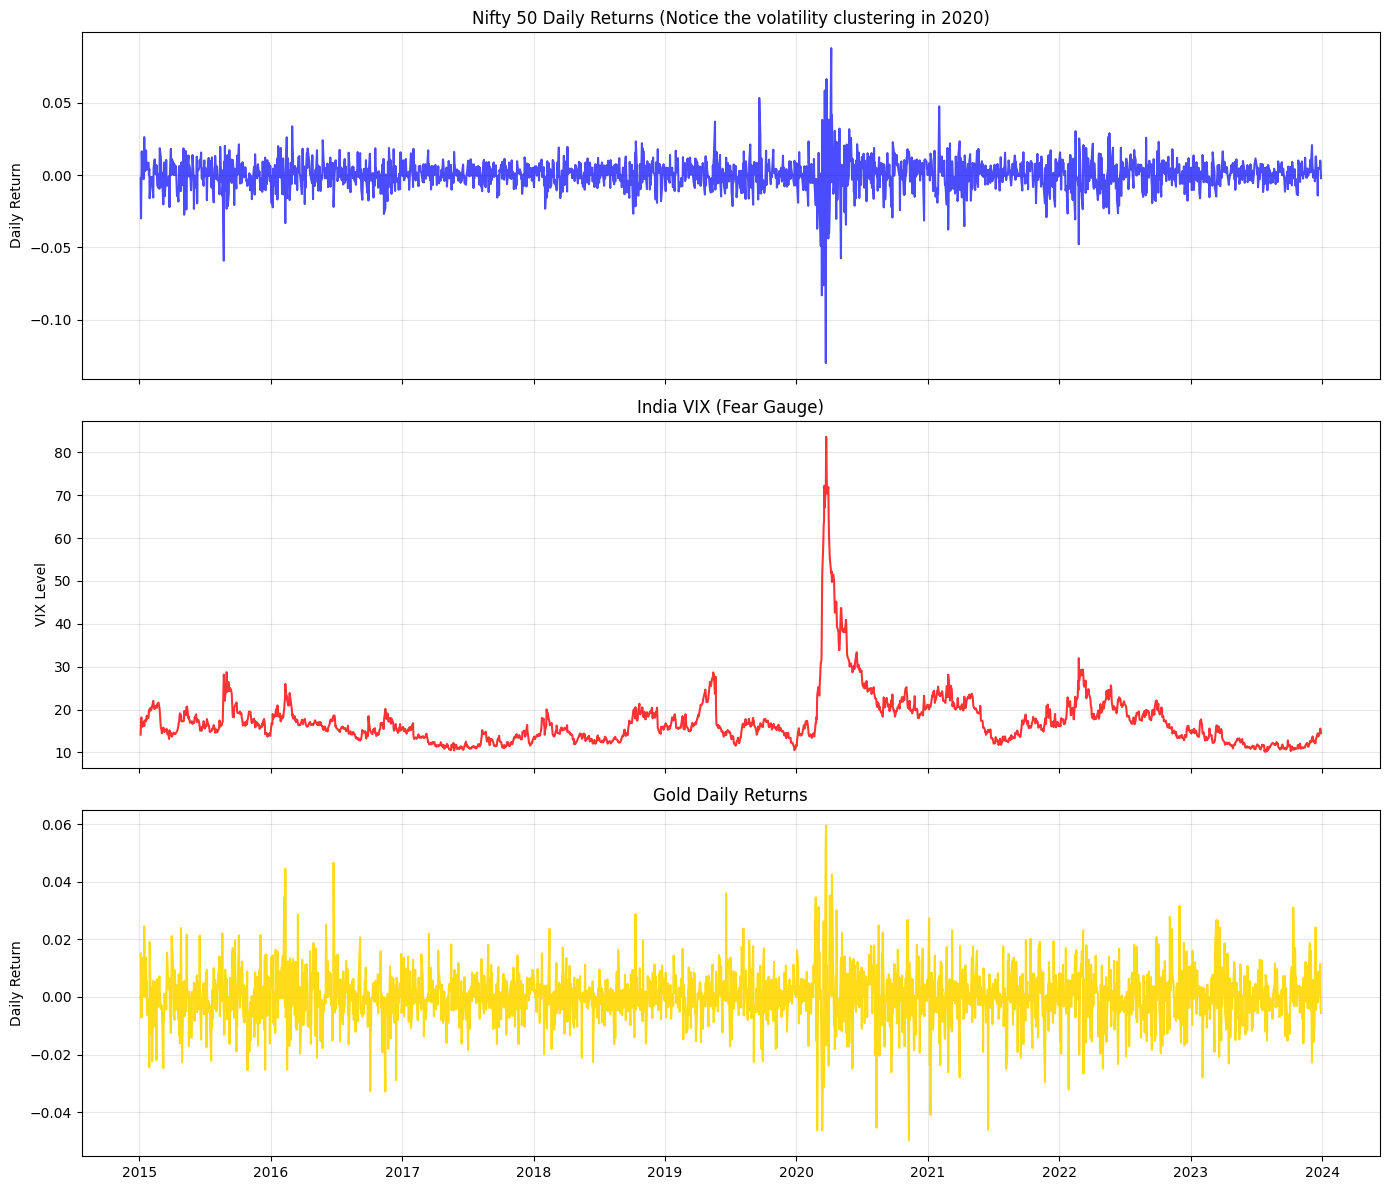

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Define the tickers and the date range
tickers = {
    'Nifty_50': '^NSEI',
    'Gold': 'GC=F',
    'Bonds': 'TLT',
    'India_VIX': '^INDIAVIX'
}

start_date = '2015-01-01'
end_date = '2024-01-01'

# 2. Download the historical data robustly
print("Downloading data...")
raw_data = pd.DataFrame()

for name, ticker in tickers.items():
    # Download each ticker individually to avoid MultiIndex parsing issues
    ticker_data = yf.download(ticker, start=start_date, end=end_date, progress=False)
    
    # Check for 'Adj Close' first, fallback to 'Close' if it doesn't exist
    if 'Adj Close' in ticker_data.columns:
        raw_data[name] = ticker_data['Adj Close']
    elif 'Close' in ticker_data.columns:
        raw_data[name] = ticker_data['Close']
    else:
        print(f"Warning: Could not find Close data for {name}")

# Forward fill any missing data (common when trading holidays differ between assets)
raw_data.ffill(inplace=True)
raw_data.dropna(inplace=True) # Drop initial rows if the starting dates misaligned

# 3. Convert prices to daily returns
print("Calculating daily returns...")
returns_data = raw_data[['Nifty_50', 'Gold', 'Bonds']].pct_change().dropna()
vix_data = raw_data['India_VIX'].loc[returns_data.index] # Align VIX dates with returns

# 4. Plot the data to visually inspect regimes
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Plot Nifty 50 Returns
axes[0].plot(returns_data.index, returns_data['Nifty_50'], color='blue', alpha=0.7)
axes[0].set_title('Nifty 50 Daily Returns (Notice the volatility clustering in 2020)')
axes[0].set_ylabel('Daily Return')
axes[0].grid(True, alpha=0.3)

# Plot India VIX
axes[1].plot(vix_data.index, vix_data, color='red', alpha=0.8)
axes[1].set_title('India VIX (Fear Gauge)')
axes[1].set_ylabel('VIX Level')
axes[1].grid(True, alpha=0.3)

# Plot Gold Returns
axes[2].plot(returns_data.index, returns_data['Gold'], color='gold', alpha=0.9)
axes[2].set_title('Gold Daily Returns')
axes[2].set_ylabel('Daily Return')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

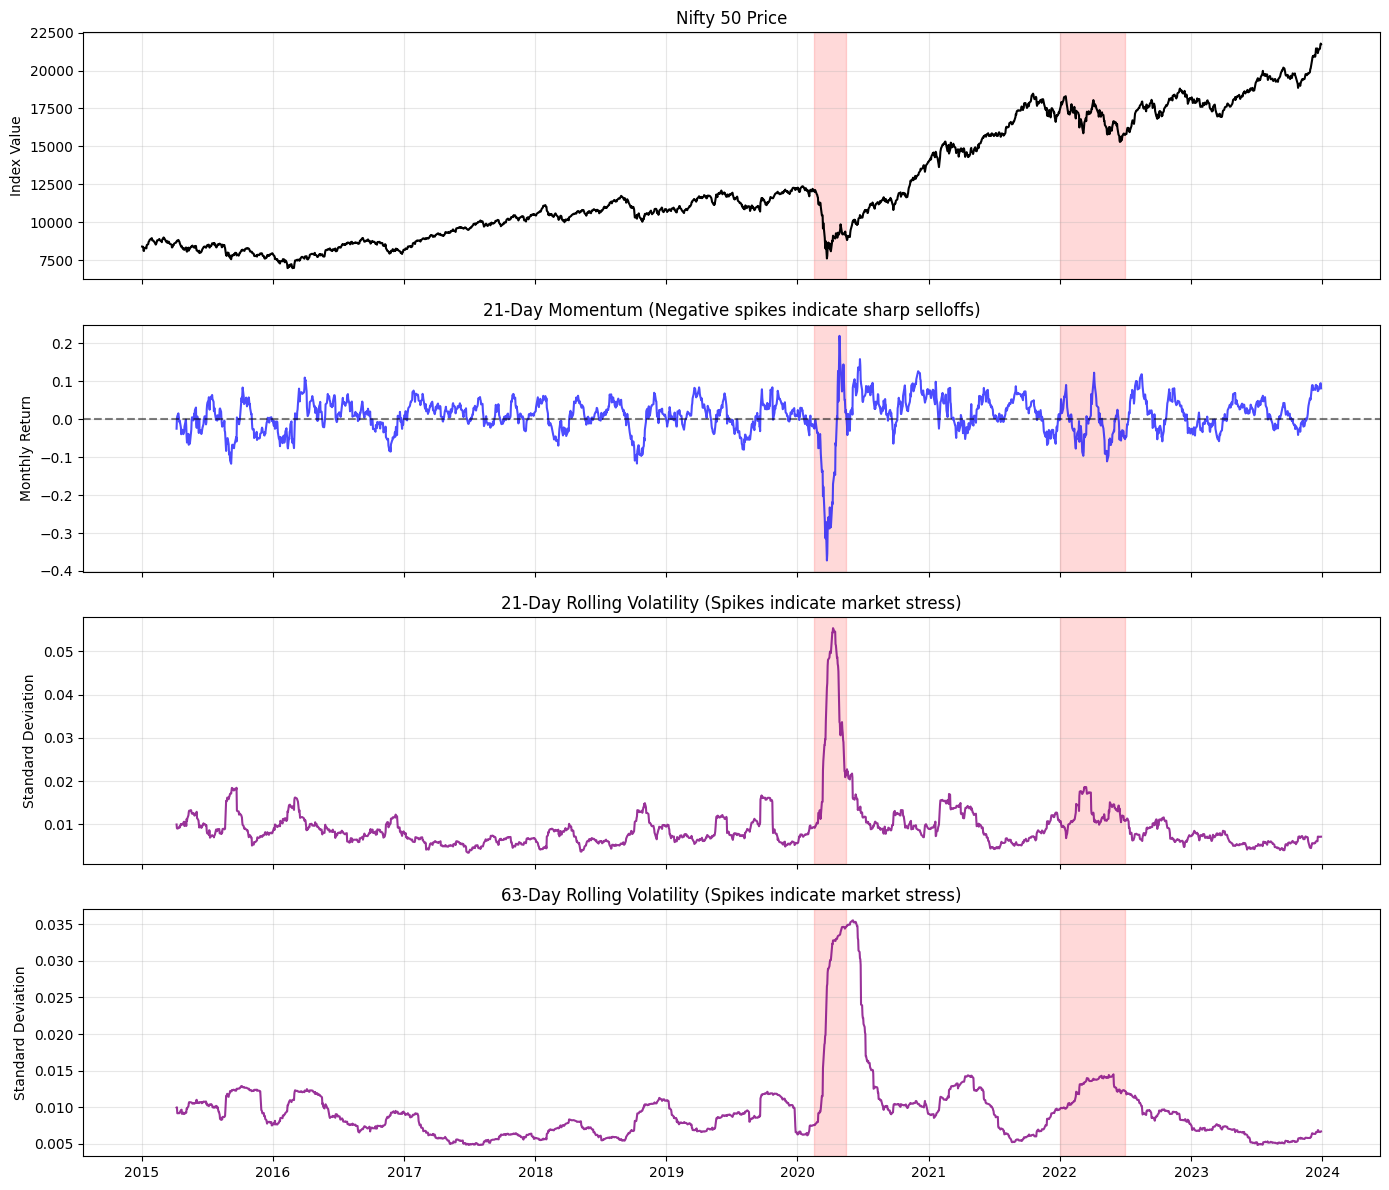

In [2]:
# 1. Initialize a DataFrame to hold our features
features = pd.DataFrame(index=raw_data.index)

# 2. Build Momentum Features (1-week, 1-month, 1-quarter)
# Assuming 21 trading days in a month
features['Mom_5D'] = raw_data['Nifty_50'].pct_change(periods=5)
features['Mom_21D'] = raw_data['Nifty_50'].pct_change(periods=21)
features['Mom_63D'] = raw_data['Nifty_50'].pct_change(periods=63)

# 3. Build Volatility Features
# 21-day rolling standard deviation of Nifty 50 daily returns
features['Vol_21D'] = returns_data['Nifty_50'].rolling(window=21).std()
features['Vol_63D'] = returns_data['Nifty_50'].rolling(window=63).std()

features['VIX_21D'] = raw_data['India_VIX'].rolling(window=21).mean()

# 4. Add the VIX as a macro volatility feature
features['VIX'] = raw_data['India_VIX']

# Drop NaN values created by the rolling windows
features.dropna(inplace=True)

# 5. Visual Sanity Check
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Highlight known stressful periods
stress_periods = [
    ('2020-02-15', '2020-05-15'), # COVID-19 Crash
    ('2022-01-01', '2022-06-30')  # 2022 Inflation/Rate Hike Selloff
]

def highlight_stress(ax):
    for start, end in stress_periods:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), color='red', alpha=0.15)

# Plot Nifty 50 Price (for reference)
axes[0].plot(raw_data.index, raw_data['Nifty_50'], color='black')
axes[0].set_title('Nifty 50 Price')
axes[0].set_ylabel('Index Value')
highlight_stress(axes[0])
axes[0].grid(True, alpha=0.3)

# Plot Momentum (21-Day)
axes[1].plot(features.index, features['Mom_21D'], color='blue', alpha=0.7)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('21-Day Momentum (Negative spikes indicate sharp selloffs)')
axes[1].set_ylabel('Monthly Return')
highlight_stress(axes[1])
axes[1].grid(True, alpha=0.3)

# Plot Volatility (21-Day Rolling Std Dev)
axes[2].plot(features.index, features['Vol_21D'], color='purple', alpha=0.8)
axes[2].set_title('21-Day Rolling Volatility (Spikes indicate market stress)')
axes[2].set_ylabel('Standard Deviation')
highlight_stress(axes[2])
axes[2].grid(True, alpha=0.3)

# Plot Volatility (21-Day Rolling Std Dev)
axes[3].plot(features.index, features['Vol_63D'], color='purple', alpha=0.8)
axes[3].set_title('63-Day Rolling Volatility (Spikes indicate market stress)')
axes[3].set_ylabel('Standard Deviation')
highlight_stress(axes[3])
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
import pandas as pd

# 2. Isolate the perfectly aligned macro features
final_features = features[['Mom_63D','Mom_21D','Vol_63D']].copy()
final_features.dropna(inplace=True)

# 3. Apply Z-Score Scaling
scaled_features = (final_features - final_features.mean()) / final_features.std()

# 4. Validate the scaling
print("Scaled Features Summary (Confirming means are ~0 and standard deviations are ~1):")
display(scaled_features.describe().loc[['mean', 'std', 'min', 'max']].round(4))

Scaled Features Summary (Confirming means are ~0 and standard deviations are ~1):


,Mom_63D,Mom_21D,Vol_63D
mean,-0.0000,-0.0000,0.0000
std,1.0000,1.0000,1.0000
min,-4.7095,-7.7091,-0.9414
max,3.8671,4.2248,5.2753


In [4]:
from hmmlearn import hmm
# 3. Fit the HMM exactly as the guide specifies
print("Fitting the HMM (Diagonal Covariance, Guide Specs)...")
model = hmm.GaussianHMM(
    n_components=3,
    covariance_type="diag",
    n_iter=1000,
    random_state=42
)

model.fit(scaled_features)
hidden_states = model.predict(scaled_features)

print("Means (scaled feature space):")
print(pd.DataFrame(
    model.means_,
    columns=scaled_features.columns
))

print("\nCovariances:")
print(model.covars_)

print("\nTransition Matrix:")
print(pd.DataFrame(model.transmat_))

Fitting the HMM (Diagonal Covariance, Guide Specs)...
Means (scaled feature space):
    Mom_63D   Mom_21D   Vol_63D
0 -0.769031 -0.162246  3.244493
1 -0.750927 -0.431568  0.143116
2  0.533527  0.281452 -0.380476

Covariances:
[[[6.98000261 0.         0.        ]
  [0.         7.31765868 0.        ]
  [0.         0.         3.43397808]]

 [[0.16619475 0.         0.        ]
  [0.         0.74612787 0.        ]
  [0.         0.         0.19646056]]

 [[0.29009013 0.         0.        ]
  [0.         0.39091009 0.        ]
  [0.         0.         0.17227625]]]

Transition Matrix:
              0             1         2
0  9.911650e-01  9.219279e-31  0.008835
1  1.285866e-03  9.856288e-01  0.013085
2  1.570064e-28  8.893178e-03  0.991107



--- Regime Mapping (Pure Volatility Heuristic) ---
Bull (State 2): Avg Volatility = 0.0076, Avg 21D Momentum = 0.0242, Avg 63D Momentum = 0.0758
Bear (State 1): Avg Volatility = 0.0101, Avg 21D Momentum = -0.0112, Avg 63D Momentum = -0.0363
Crisis (State 0): Avg Volatility = 0.0255, Avg 21D Momentum = 0.0016, Avg 63D Momentum = -0.0394


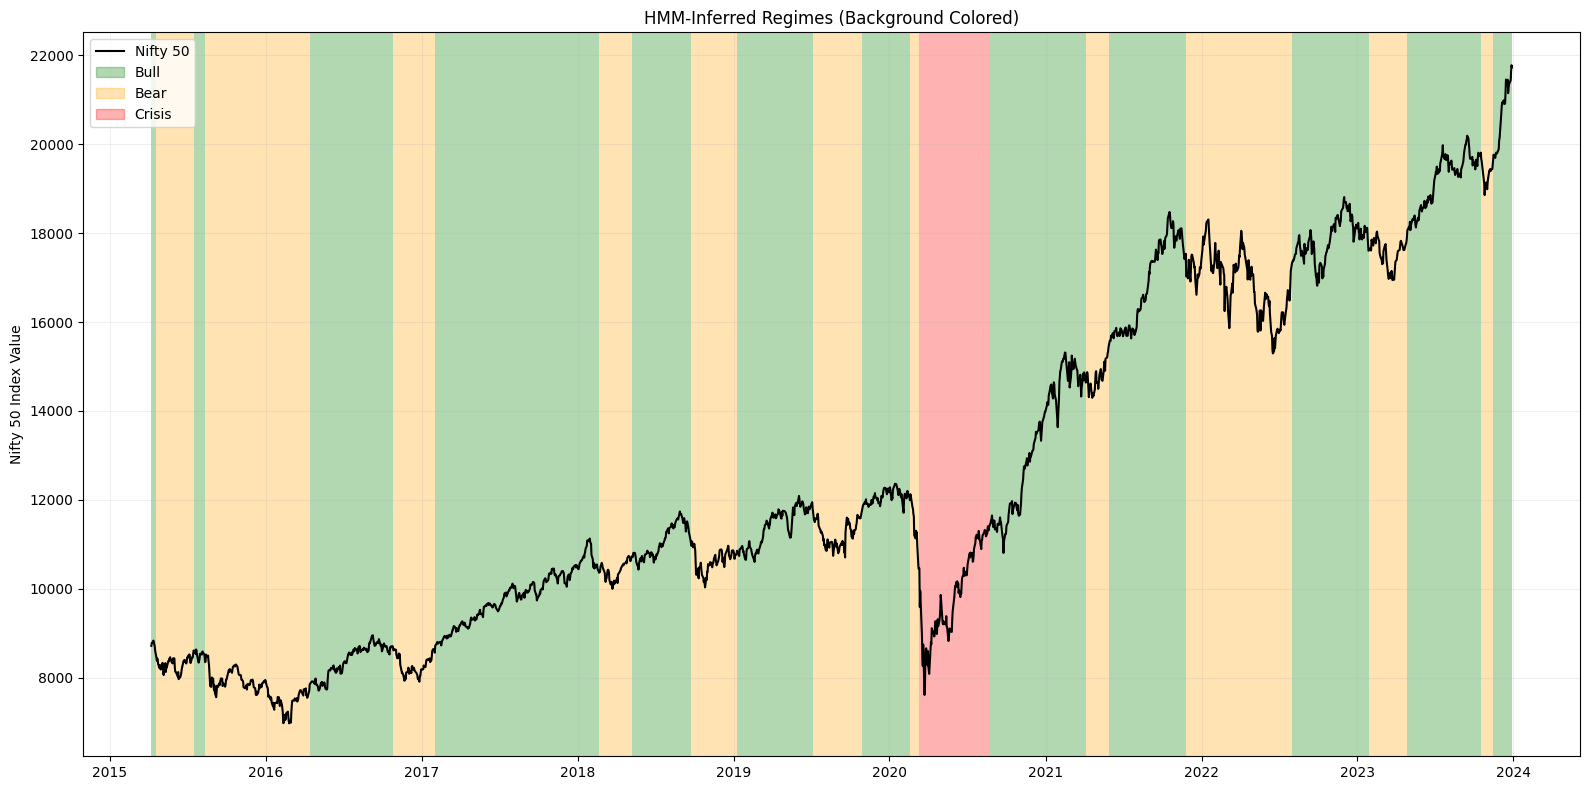

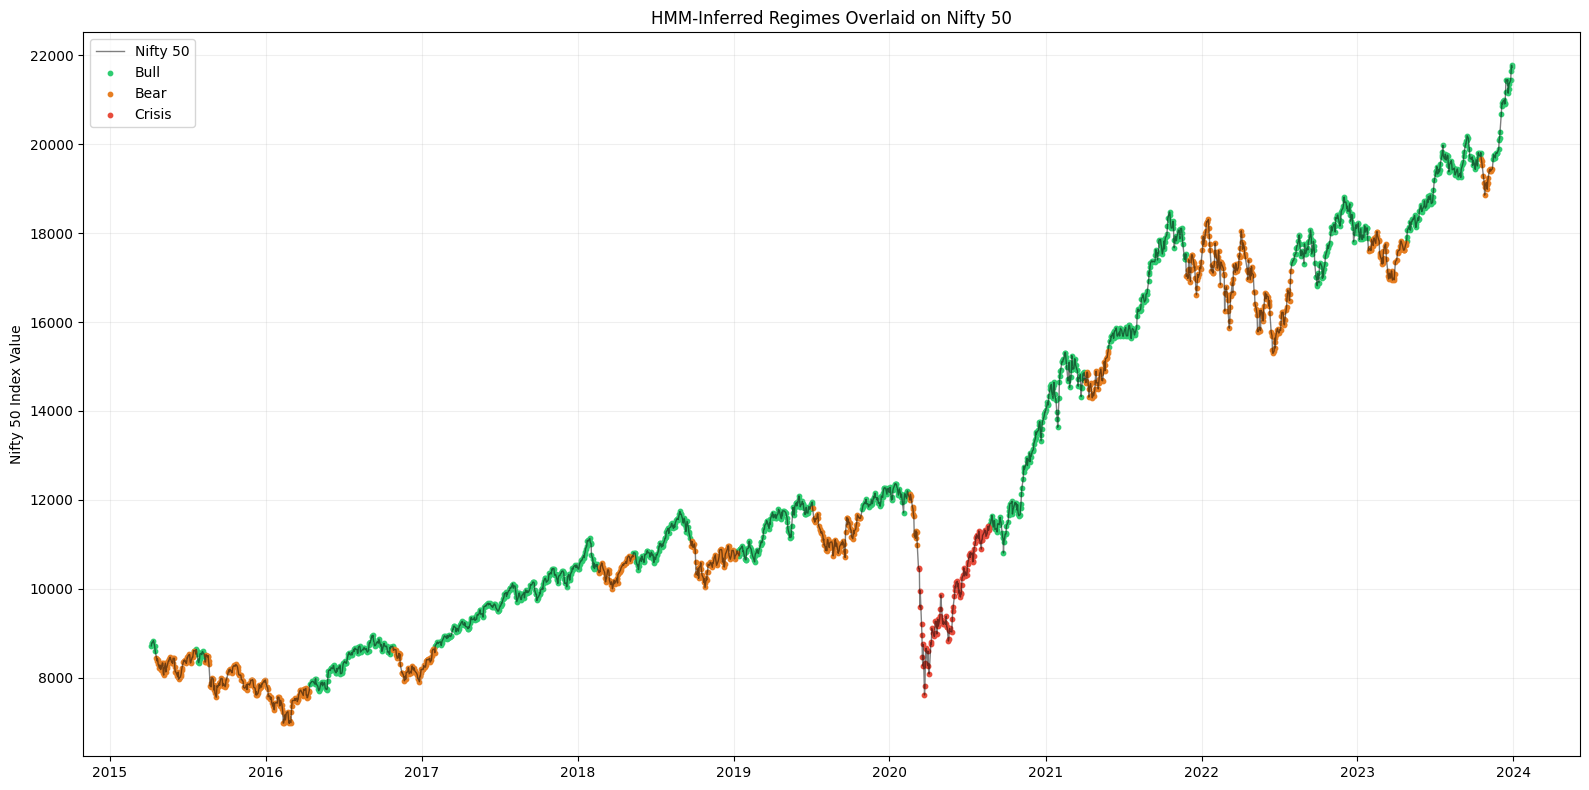

In [5]:
import matplotlib.patches as mpatches
# ==========================================================
# 4. Pure Volatility Mapping (Directly from the guide)
# ==========================================================

state_stats = []

for i in range(3):
    mask = (hidden_states == i)

    if mask.sum() > 0:
        state_vol = final_features.loc[mask, "Vol_63D"].mean()
        state_mom_21 = final_features.loc[mask, "Mom_21D"].mean()
        state_mom_63 = final_features.loc[mask, "Mom_63D"].mean()
    else:
        state_vol = 0
        state_mom_21 = 0
        state_mom_63 = 0

    state_stats.append({
        "state": i,
        "vol": state_vol,
        "mom21": state_mom_21,
        "mom63": state_mom_63,
    })

stats_df = pd.DataFrame(state_stats).sort_values(by="vol")

# Lowest vol = Bull, Middle vol = Bear, Highest vol = Crisis
bull_state = int(stats_df.iloc[0]["state"])
bear_state = int(stats_df.iloc[1]["state"])
crisis_state = int(stats_df.iloc[2]["state"])

regime_map = {
    bull_state: "Bull",
    bear_state: "Bear",
    crisis_state: "Crisis"
}

color_map = {
    bull_state: "green",
    bear_state: "orange",
    crisis_state: "red"
}

print("\n--- Regime Mapping (Pure Volatility Heuristic) ---")
for _, row in stats_df.iterrows():
    state = int(row["state"])
    print(
    f"{regime_map[state]} (State {state}): "
    f"Avg Volatility = {row['vol']:.4f}, "
    f"Avg 21D Momentum = {row['mom21']:.4f}, "
    f"Avg 63D Momentum = {row['mom63']:.4f}"
)

# ==========================================================
# Create dataframe for plotting
# ==========================================================

feat_df = final_features.copy()
feat_df["state"] = hidden_states
feat_df["regime_label"] = feat_df["state"].map(regime_map)

aligned_price = raw_data.loc[feat_df.index, "Nifty_50"]

# ==========================================================
# Plot 1: Background-colored regimes
# ==========================================================

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(
    aligned_price.index,
    aligned_price,
    color="black",
    linewidth=1.5,
    label="Nifty 50"
)

for i in range(len(feat_df) - 1):
    ax.axvspan(
        feat_df.index[i],
        feat_df.index[i + 1],
        color=color_map[hidden_states[i]],
        alpha=0.3,
        lw=0
    )

legend_patches = [
    mpatches.Patch(
        color=color_map[state],
        alpha=0.3,
        label=regime_map[state]
    )
    for state in regime_map
]

ax.legend(handles=[ax.lines[0]] + legend_patches, loc="upper left")

ax.set_title("HMM-Inferred Regimes (Background Colored)")
ax.set_ylabel("Nifty 50 Index Value")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# ==========================================================
# Plot 2: Scatter plot with regime labels (Guide style)
# ==========================================================

fig, ax = plt.subplots(figsize=(16, 8))

# Plot price as a faint line
ax.plot(
    aligned_price.index,
    aligned_price,
    color="black",
    linewidth=1,
    alpha=0.5,
    label="Nifty 50"
)

scatter_colors = {
    "Bull": "#2ecc71",
    "Bear": "#e67e22",
    "Crisis": "#e74c3c"
}

for label, color in scatter_colors.items():
    mask = feat_df["regime_label"] == label

    ax.scatter(
        feat_df.index[mask],
        aligned_price.loc[mask],
        s=10,
        color=color,
        label=label
    )

ax.set_title("HMM-Inferred Regimes Overlaid on Nifty 50")
ax.set_ylabel("Nifty 50 Index Value")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Model is not converging.  Current: -3479.0332822192463 is not greater than -3478.9882285766025. Delta is -0.04505364264377931
Model is not converging.  Current: -2725.457012900252 is not greater than -2725.4170277728535. Delta is -0.03998512739826765


Starting Walk-Forward Validation with Sticky Priors...


Model is not converging.  Current: -4059.44353405382 is not greater than -4059.4363613302316. Delta is -0.00717272358815535
Model is not converging.  Current: -4112.4619944804235 is not greater than -4112.45732851522. Delta is -0.004665965203457745


Walk-Forward Validation Complete!


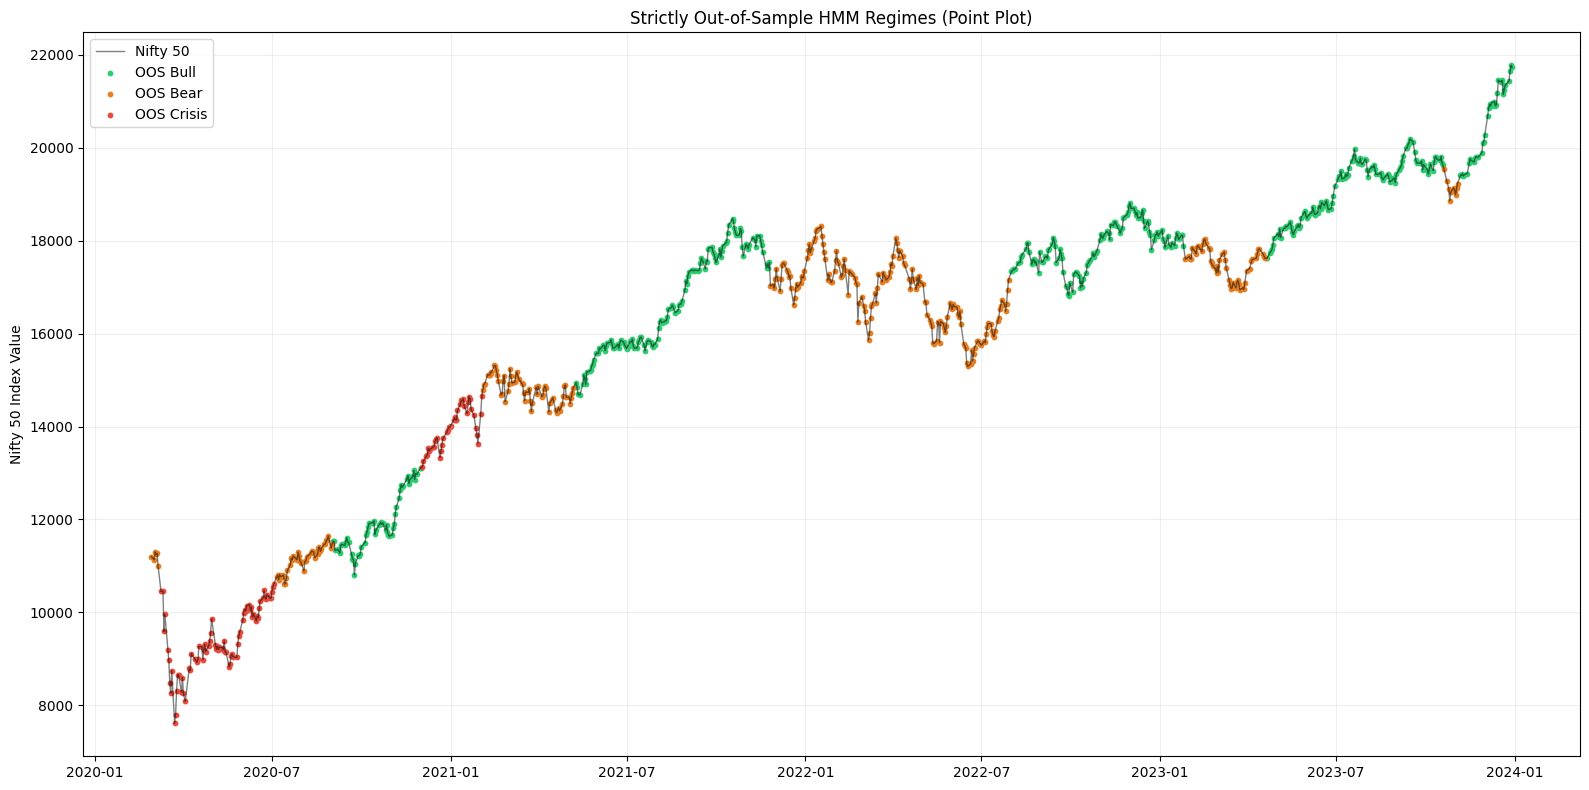

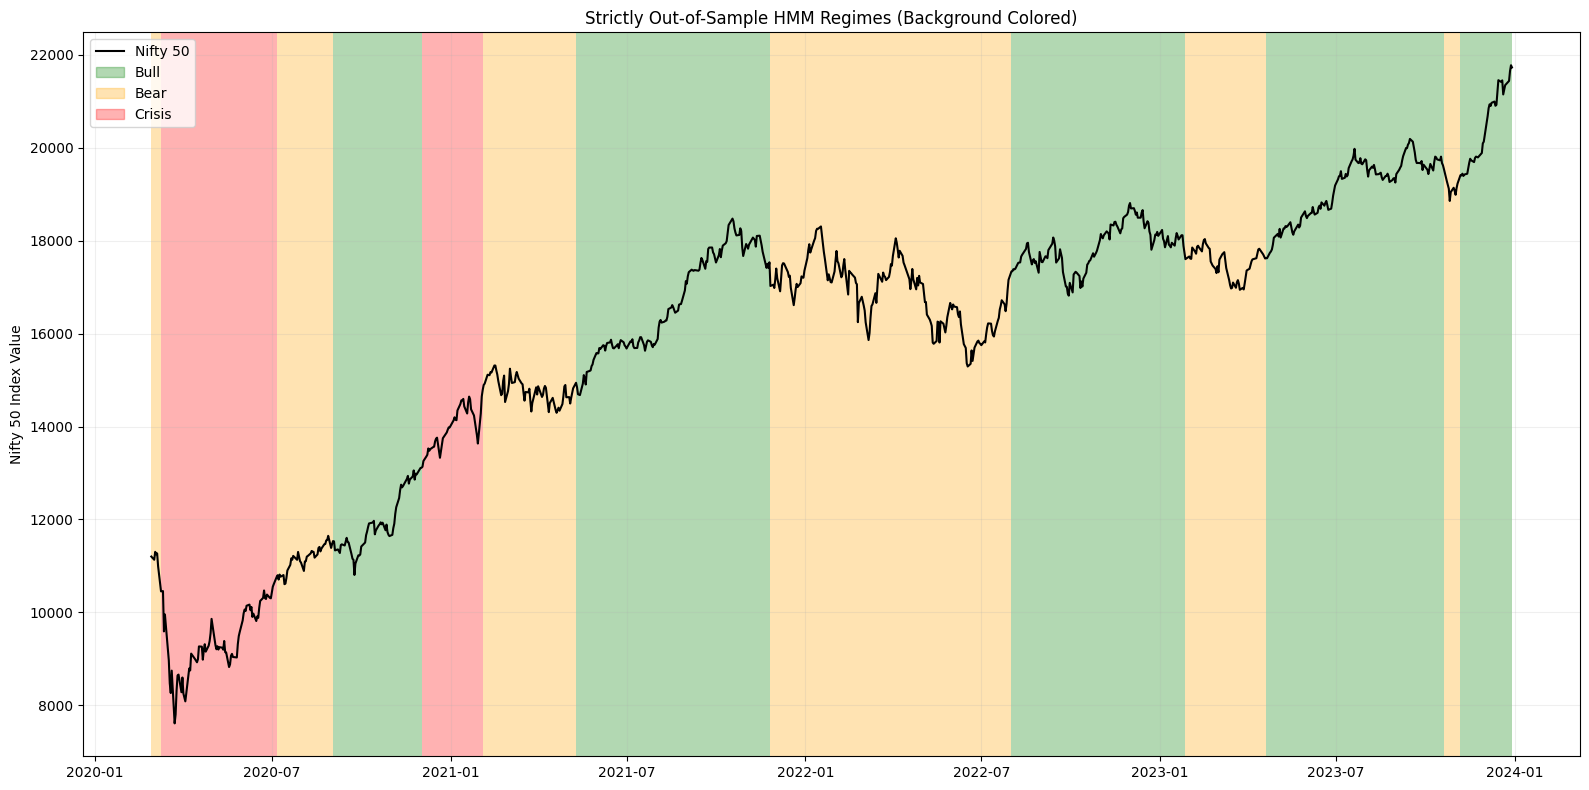

In [6]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

# ==========================================================
# 1. Walk-Forward Validation Harness (Phase 4)
# ==========================================================

start_idx = 1200
step_size = 21 

oos_labels = []
oos_dates = []

print("Starting Walk-Forward Validation with Sticky Priors...")

for i in range(start_idx, len(final_features), step_size):
    
    # A. Isolate the strict training data 
    train_features = final_features.iloc[:i]
    
    # B. Strict Scaling
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_features)
    
    # C. Fit HMM strictly on historical data
    model = hmm.GaussianHMM(n_components=3, covariance_type="diag", n_iter=200, random_state=42)
    
    # ---> THE FIX: Inject strong diagonal priors to prevent whipsaws <---
    model.transmat_prior = np.eye(3) * 1000 + 1.0 
    
    model.fit(train_scaled)
    
    # D. Determine state mapping logic
    train_states = model.predict(train_scaled)
    train_temp = train_features.copy()
    train_temp['state'] = train_states
    
    state_vol = train_temp.groupby('state')['Vol_63D'].mean().sort_values()
    label_map = {state_vol.index[0]: 'Bull', state_vol.index[1]: 'Bear', state_vol.index[2]: 'Crisis'}
    
    # E. Out-of-Sample (OOS) Prediction
    end_idx = min(i + step_size, len(final_features))
    test_sequence = final_features.iloc[:end_idx]
    test_scaled = scaler.transform(test_sequence)
    
    sequence_predictions = model.predict(test_scaled)
    new_predictions = sequence_predictions[i:end_idx]
    
    # F. Map to string labels and store
    for p in new_predictions:
        oos_labels.append(label_map[p])
        
    oos_dates.extend(final_features.index[i:end_idx])

oos_regimes = pd.Series(oos_labels, index=oos_dates, name="OOS_Regime")
print("Walk-Forward Validation Complete!")

# ==========================================================
# 2. Plot strictly Out-Of-Sample Regimes (Scatter Plot)
# ==========================================================

oos_price = raw_data.loc[oos_regimes.index, "Nifty_50"]
fig, ax = plt.subplots(figsize=(16, 8))

# Plot price as a faint line
ax.plot(oos_price.index, oos_price, color="black", linewidth=1, alpha=0.5, label="Nifty 50")

scatter_colors = {
    "Bull": "#2ecc71",
    "Bear": "#e67e22",
    "Crisis": "#e74c3c"
}

for label, color in scatter_colors.items():
    mask = oos_regimes == label
    ax.scatter(oos_regimes.index[mask], oos_price.loc[mask], s=10, color=color, label=f"OOS {label}")

ax.set_title("Strictly Out-of-Sample HMM Regimes (Point Plot)")
ax.set_ylabel("Nifty 50 Index Value")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# ==========================================================
# 3. Plot strictly Out-Of-Sample Regimes (Background Colored)
# ==========================================================

fig, ax = plt.subplots(figsize=(16, 8))

ax.plot(oos_price.index, oos_price, color="black", linewidth=1.5, label="Nifty 50")

oos_color_map = {
    "Bull": "Green",  
    "Bear": "Orange",  
    "Crisis": "Red" 
}

for i in range(len(oos_regimes) - 1):
    ax.axvspan(
        oos_regimes.index[i],
        oos_regimes.index[i + 1],
        color=oos_color_map[oos_regimes.iloc[i]],
        alpha=0.3,
        lw=0
    )

legend_patches = [mpatches.Patch(color=color, alpha=0.3, label=label) for label, color in oos_color_map.items()]
ax.legend(handles=[ax.lines[0]] + legend_patches, loc="upper left")

ax.set_title("Strictly Out-of-Sample HMM Regimes (Background Colored)")
ax.set_ylabel("Nifty 50 Index Value")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [7]:
import cvxpy as cp
import numpy as np
import pandas as pd

def optimize_regime_portfolio(expected_returns, cov_matrix, regime):
    """
    Calculates optimal portfolio weights based on the current HMM market regime.
    
    expected_returns: numpy array of historical mean returns
    cov_matrix: numpy 2D array of the covariance matrix
    regime: string ('Bull', 'Bear', 'Crisis')
    """
    n_assets = len(expected_returns)
    
    # Define the variable we are solving for: the asset weights
    w = cp.Variable(n_assets)
    
    # Universal Constraints: 
    # 1. Weights must sum to 1 (100% invested)
    # 2. Weights must be positive (Long-only, no shorting)
    constraints = [
        cp.sum(w) == 1,
        w >= 0
    ]

    # ---------------------------------------------------------
    # BULL REGIME: Maximize Risk-Adjusted Return
    # ---------------------------------------------------------
    if regime == 'Bull':
        # Gamma is the risk aversion penalty. Lower gamma = more aggressive.
        gamma = cp.Parameter(nonneg=True, value= 0.5)
        
        # Objective: Maximize (Returns - Penalty * Variance)
        ret = w.T @ expected_returns
        risk = cp.quad_form(w, cov_matrix)
        objective = cp.Maximize(ret - (gamma / 2) * risk)

    # ---------------------------------------------------------
    # BEAR REGIME: Minimize Volatility
    # ---------------------------------------------------------
    elif regime == 'Bear':
        # Objective: Strictly minimize portfolio variance.
        risk = cp.quad_form(w, cov_matrix)
        objective = cp.Minimize(risk)
        
        # Optional: Cap max allocation to any single risky asset at 40%
        constraints.append(w <= 0.40)

    # ---------------------------------------------------------
    # CRISIS REGIME: Capital Preservation
    # ---------------------------------------------------------
    elif regime == 'Crisis':
        # Objective: Minimize variance, but force liquidity.
        risk = cp.quad_form(w, cov_matrix)
        objective = cp.Minimize(risk)
        
        # Assuming the last asset in our array is a Cash/Safe-Haven ETF (e.g., Liquid Fund or Gold)
        # Force a minimum of 50% capital into the safe-haven asset
        safe_asset_index = n_assets - 1
        constraints.append(w[safe_asset_index] >= 0.50)

    # Solve the convex problem
    prob = cp.Problem(objective, constraints)
    
    try:
        prob.solve()
        # Clean up near-zero weights (e.g., 1e-12) generated by the solver
        cleaned_weights = np.round(w.value, 4)
        return cleaned_weights
    except Exception as e:
        print(f"Solver failed for regime {regime}: {e}")
        # Fallback to equal weight if solver fails
        return np.ones(n_assets) / n_assets

# ==========================================
# Demonstration of the Solver Output
# ==========================================
# Mock Data: Asset 0 (Equities), Asset 1 (Gold), Asset 2 (Cash/Bonds)
mock_returns = np.array([0.012, 0.005, 0.002])
mock_cov = np.array([
    [ 0.0400, -0.0050,  0.0010],
    [-0.0050,  0.0200,  0.0005],
    [ 0.0010,  0.0005,  0.0001]
])

print("Target Asset Universe: [Equities, Gold, Cash]")
for current_regime in ['Bull', 'Bear', 'Crisis']:
    optimal_w = optimize_regime_portfolio(mock_returns, mock_cov, current_regime)
    print(f"{current_regime} Allocation: {optimal_w}")

Target Asset Universe: [Equities, Gold, Cash]
Bull Allocation: [ 0.5571  0.4429 -0.    ]
Bear Allocation: [0.2114 0.3886 0.4   ]
Crisis Allocation: [0. 0. 1.]


In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# Phase 6: Backtesting and Benchmarking
# ==========================================================

# ----------------------------------------------------------
# 1. Dynamic Strategy Engine (Task 1 & Task 2)
# ----------------------------------------------------------
def simulate_dynamic_strategy(returns_df, regimes_series, transaction_cost=0.0010, lookback=126):
    """
    Simulates the HMM strategy by dynamically calling the CVXPY optimizer (Phase 5).
    Applies transaction costs based on portfolio turnover.
    """
    n_days = len(returns_df)
    n_assets = returns_df.shape[1]
    
    strat_returns = np.zeros(n_days)
    turnover_array = np.zeros(n_days)
    
    # Start in cash to bootstrap the first lookback period
    current_weights = np.array([0.0, 0.0, 1.0]) 
    target_weights = current_weights.copy()
    
    for i in range(n_days):
        regime = regimes_series.iloc[i]
        daily_asset_returns = returns_df.iloc[i].values
        
        # Only re-optimize if we have enough historical data AND 
        # it's a regime change OR a standard 21-day monthly rebalance
        if i >= lookback:
            regime_changed = (i > 0) and (regime != regimes_series.iloc[i-1])
            time_to_rebalance = (i % 21 == 0)
            
            if regime_changed or time_to_rebalance:
                # Calculate trailing statistics strictly on past data (No Lookahead Bias)
                past_returns = returns_df.iloc[i-lookback : i]
                expected_returns = past_returns.mean().values * 252
                cov_matrix = past_returns.cov().values * 252
                
                # Dynamically solve for optimal weights using CVXPY based on the regime
                target_weights = optimize_regime_portfolio(expected_returns, cov_matrix, regime)
        
        # Calculate Turnover and apply the 10 bps friction
        turnover = np.sum(np.abs(target_weights - current_weights))
        turnover_array[i] = turnover
        gross_return = np.dot(current_weights, daily_asset_returns)
        net_return = gross_return - (turnover * transaction_cost)
        
        strat_returns[i] = net_return
        current_weights = target_weights
        
    ann_turnover = turnover_array.mean() * 252
    return pd.Series(strat_returns, index=returns_df.index), ann_turnover

In [28]:
def calculate_metrics(returns_series, ann_turnover, risk_free_rate=0.0):
    # Annualization factors (assuming 252 trading days)
    ann_factor = 252
    
    # 1. Annualized Return & Volatility
    ann_return = returns_series.mean() * ann_factor
    ann_vol = returns_series.std() * np.sqrt(ann_factor)
    
    # 2. Sharpe Ratio
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol != 0 else 0
    
    # 3. Sortino Ratio (punishes only negative volatility)
    negative_returns = returns_series[returns_series < 0]
    downside_vol = negative_returns.std() * np.sqrt(ann_factor)
    sortino = (ann_return - risk_free_rate) / downside_vol if downside_vol != 0 else 0
    
    # 4. Maximum Drawdown
    cumulative_returns = (1 + returns_series).cumprod()
    rolling_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # 5. Calmar Ratio
    calmar = ann_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    return {
        "Ann Return": round(ann_return, 4),
        "Ann Volatility": round(ann_vol, 4),
        "Sharpe Ratio": round(sharpe, 2),
        "Sortino Ratio": round(sortino, 2),
        "Max Drawdown": round(max_drawdown, 4),
        "Calmar Ratio": round(calmar, 2),
        "Ann Turnover": round(ann_turnover, 2) # NEW: Added to final output
    }

In [29]:
# ----------------------------------------------------------
# 3. Static Benchmark Engine (Task 3)
# ----------------------------------------------------------
def simulate_static_strategy(returns_df, target_weights, transaction_cost=0.0010):
    n_days = len(returns_df)
    n_assets = returns_df.shape[1]
    
    strat_returns = np.zeros(n_days)
    turnover_array = np.zeros(n_days)
    current_weights = np.zeros(n_assets)
    
    for i in range(n_days):
        daily_asset_returns = returns_df.iloc[i].values
        
        if i == 0 or i % 21 == 0:
            turnover = np.sum(np.abs(target_weights - current_weights))
            current_weights = target_weights.copy()
        else:
            turnover = 0.0
            
        turnover_array[i] = turnover
        gross_return = np.dot(current_weights, daily_asset_returns)
        net_return = gross_return - (turnover * transaction_cost)
        
        strat_returns[i] = net_return
        
    ann_turnover = turnover_array.mean() * 252
    return pd.Series(strat_returns, index=returns_df.index), ann_turnover

In [31]:
# ----------------------------------------------------------
# 4. Execution & Metric Calculation (Strict Project Compliance)
# ----------------------------------------------------------
print("Running CVXPY Dynamic Optimization Backtest (This takes a few seconds)...")

# --- STRICT ALIGNMENT: [Equities, Gold, Cash] ---
# 1. Extract Nifty 50 and Gold from your Phase 1 real data
multi_asset_returns = returns_data[['Nifty_50', 'Gold']].copy()

# 2. Generate the Cash Asset (Asset 3) as demanded by Phase 5
# Assuming a standard 5% annualized yield for an Indian Liquid Fund / Cash equivalent
cash_returns = pd.Series(0.05 / 252, index=multi_asset_returns.index)
multi_asset_returns['Cash'] = cash_returns

# 3. Rename to match the optimizer's expectations perfectly
multi_asset_returns.columns = ['Equities', 'Bonds_Gold', 'Cash']

# Align dates strictly with the out-of-sample regimes from Phase 4
multi_asset_returns = multi_asset_returns.loc[oos_regimes.index]
# ----------------------------------------------------------------

# Define Static Benchmark Weights: [Equities, Bonds_Gold, Cash]
weights_60_40 = np.array([0.60, 0.40, 0.00])
weights_equal = np.array([0.3333, 0.3333, 0.3334])

# Execute Simulations (With and Without 10 bps friction)
dyn_ret_10bps, dyn_turn_10bps = simulate_dynamic_strategy(multi_asset_returns, oos_regimes, transaction_cost=0.0010, lookback=10)
dyn_ret_0bps, dyn_turn_0bps = simulate_dynamic_strategy(multi_asset_returns, oos_regimes, transaction_cost=0.0000, lookback=10)

bmk_6040_ret, bmk_6040_turn = simulate_static_strategy(multi_asset_returns, weights_60_40, transaction_cost=0.0010)
bmk_eqwt_ret, bmk_eqwt_turn = simulate_static_strategy(multi_asset_returns, weights_equal, transaction_cost=0.0010)

metrics_df = pd.DataFrame({
    "Dynamic HMM (0 bps Cost)": calculate_metrics(dyn_ret_0bps, dyn_turn_0bps),
    "Dynamic HMM (10 bps Cost)": calculate_metrics(dyn_ret_10bps, dyn_turn_10bps),
    "Static 60/40 Benchmark": calculate_metrics(bmk_6040_ret, bmk_6040_turn),
    "Equal Weight Benchmark": calculate_metrics(bmk_eqwt_ret, bmk_eqwt_turn)
})

print("=" * 85)
print("             PHASE 6: STRATEGY PERFORMANCE METRICS             ")
print("=" * 85)
display(metrics_df)

Running CVXPY Dynamic Optimization Backtest (This takes a few seconds)...
             PHASE 6: STRATEGY PERFORMANCE METRICS             


,Dynamic HMM (0 bps Cost),Dynamic HMM (10 bps Cost),Static 60/40 Benchmark,Equal Weight Benchmark
Ann Return,0.1665,0.1586,0.1419,0.1037
Ann Volatility,0.0935,0.0934,0.1416,0.0897
Sharpe Ratio,1.7800,1.7000,1.0000,1.1600
Sortino Ratio,2.3100,2.2000,1.2100,1.4500
Max Drawdown,-0.0777,-0.0840,-0.2233,-0.1343
Calmar Ratio,2.1400,1.8900,0.6400,0.7700
Ann Turnover,7.9000,7.9000,0.2700,0.2700


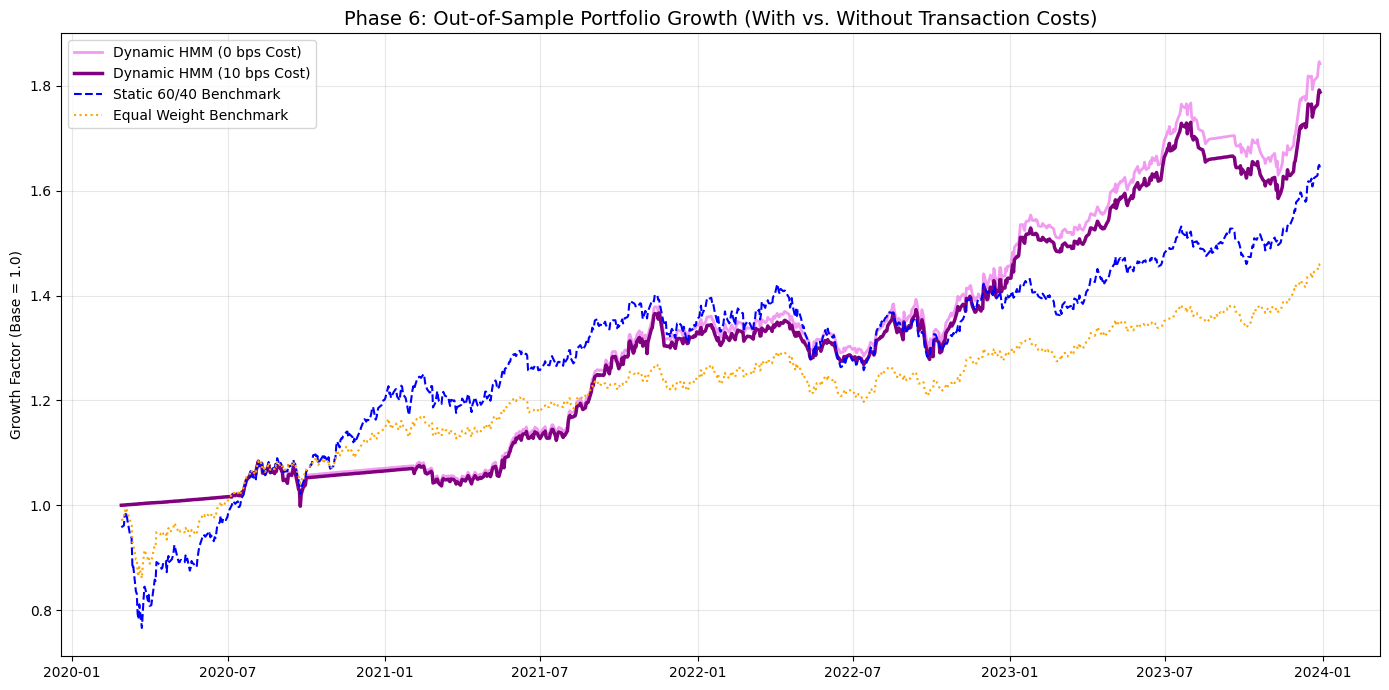

In [32]:
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 5. Plot Equity Curves
# ----------------------------------------------------------
plt.figure(figsize=(14, 7))

# Plot Dynamic Strategy (With and Without Friction)
plt.plot((1 + dyn_ret_0bps).cumprod(), label="Dynamic HMM (0 bps Cost)", color="violet", linewidth=2.0, alpha=0.8)
plt.plot((1 + dyn_ret_10bps).cumprod(), label="Dynamic HMM (10 bps Cost)", color="purple", linewidth=2.5)

# Plot Static Benchmarks
plt.plot((1 + bmk_6040_ret).cumprod(), label="Static 60/40 Benchmark", color="blue", linestyle="--")
plt.plot((1 + bmk_eqwt_ret).cumprod(), label="Equal Weight Benchmark", color="orange", linestyle=":")

# Formatting
plt.title("Phase 6: Out-of-Sample Portfolio Growth (With vs. Without Transaction Costs)", fontsize=14)
plt.ylabel("Growth Factor (Base = 1.0)")
plt.legend(loc="upper left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

--- DIAGNOSTIC RESULTS ---
Total Regime Changes (Whipsaws): 13

Dynamic HMM Strategy (0 bps Friction):


{'Ann Return': 0.1503,
 'Ann Volatility': 0.0962,
 'Sharpe Ratio': 1.56,
 'Sortino Ratio': 2.1,
 'Max Drawdown': -0.0987,
 'Calmar Ratio': 1.52}